## Fabric Classification

In [1]:
print("Hello World")

Hello World


In [2]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from PIL import Image

In [11]:
DATA_DIR    = "/kaggle/input/datasets/venky2729/patse-data/data_pattern"  # ← edit to your dataset path
OUTPUT_DIR  = "/kaggle/working/"
 
SEED        = 42
IMG_SIZE    = 224          # required by ResNet50; CNN uses same for consistency
TRAIN_FRAC  = 0.70
VAL_FRAC    = 0.15
TEST_FRAC   = 0.15
BATCH_SIZE  = 32
 
# CNN-specific
CNN_EPOCHS      = 60
CNN_LR          = 3e-4
CNN_WEIGHT_DECAY = 1e-4
 
# ResNet50-specific  (2-phase: warm up head → full fine-tune)
R50_EPOCHS      = 40
R50_HEAD_LR     = 1e-3     # phase 1: head only, backbone frozen
R50_FINETUNE_LR = 5e-5     # phase 2: full model, low LR
R50_HEAD_EPOCHS = 5
R50_WEIGHT_DECAY = 1e-4
 
EARLY_STOP_PATIENCE = 10   # shared by both models
 
# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [12]:
VALID_EXTS  = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
CLASSES     = sorted(d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d)))
NUM_CLASSES = len(CLASSES)
label_to_idx = {cls: i for i, cls in enumerate(CLASSES)}
idx_to_label = {i: cls for cls, i in label_to_idx.items()}
 
print(f"Classes ({NUM_CLASSES}): {CLASSES}")
 
records, bad_files = [], []
for cls in CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    for fname in sorted(os.listdir(cls_dir)):
        if os.path.splitext(fname)[1].lower() not in VALID_EXTS:
            continue
        fpath = os.path.join(cls_dir, fname)
        try:
            with Image.open(fpath) as img:
                img.verify()
            records.append({"path": fpath, "label": cls, "label_idx": label_to_idx[cls]})
        except Exception:
            bad_files.append(fpath)
 
df = pd.DataFrame(records)
print(f"Valid images: {len(df)}   |   Corrupt / skipped: {len(bad_files)}")
assert len(df) > 0, "No images found — check DATA_DIR."
 
df.to_csv(os.path.join(OUTPUT_DIR, "patse_dataset.csv"), index=False)
 
print("\nClass distribution:")
for cls, n in df['label'].value_counts().sort_index().items():
    print(f"  {cls:<15} {n:>4}")

Classes (10): ['animal', 'cartoon', 'floral', 'geometry', 'ikat', 'plain', 'polka dot', 'squares', 'stripes', 'tribal']
Valid images: 4230   |   Corrupt / skipped: 0

Class distribution:
  animal           351
  cartoon          260
  floral           495
  geometry         339
  ikat             355
  plain            497
  polka dot        498
  squares          439
  stripes          500
  tribal           496


In [13]:
X = df["path"].values
y = df["label_idx"].values
 
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=(VAL_FRAC + TEST_FRAC), stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC), stratify=y_tmp, random_state=SEED
)
print(f"Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")

Train: 2961  |  Val: 634  |  Test: 635


In [14]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
 
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
 
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
 
 
class PatSeDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform
 
    def __len__(self):
        return len(self.paths)
 
    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, int(self.labels[idx])

In [15]:
class_counts  = pd.Series(y_train).value_counts().sort_index()
sample_weights = (1.0 / class_counts.loc[y_train].values)
 
sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
 
# Sqrt-dampened class weights for the loss function.
# Dampening avoids double-correcting when sampler already handles imbalance.
inv_freq          = (1.0 / class_counts) * len(y_train) / NUM_CLASSES
loss_class_weights = torch.tensor(np.sqrt(inv_freq.values), dtype=torch.float32).to(device)
 
train_dataset = PatSeDataset(X_train, y_train, transform=train_transform)
val_dataset   = PatSeDataset(X_val,   y_val,   transform=eval_transform)
test_dataset  = PatSeDataset(X_test,  y_test,  transform=eval_transform)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,    num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,       num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,       num_workers=2, pin_memory=True)
 
print(f"Batches — Train: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}")

Batches — Train: 93  Val: 20  Test: 20


In [16]:
class PatSeCNN(nn.Module):
    """
    4-block CNN built for 224×224 RGB input.
    After 4× MaxPool2d(2,2):  224 → 112 → 56 → 28 → 14
    Final feature map: 64 channels × 14 × 14 = 12 544 → classifier.
    """
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3,  32, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),                          # 112×112
 
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2),                          # 56×56
 
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.Conv2d(128,128, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.MaxPool2d(2, 2),                           # 28×28
 
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.MaxPool2d(2, 2),                            # 14×14
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512), nn.ReLU(), nn.Dropout(p=0.5),
            nn.Linear(512, 256),           nn.ReLU(), nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )
 
    def forward(self, x):
        return self.classifier(self.features(x))
 
 
cnn_model = PatSeCNN(NUM_CLASSES).to(device)
n_params  = sum(p.numel() for p in cnn_model.parameters())
print(f"CNN — Total parameters: {n_params:,}")

CNN — Total parameters: 26,998,698


In [17]:
def run_epoch(model, loader, loss_fn, optimizer=None, train_mode=True):
    model.train() if train_mode else model.eval()
    total_loss, total, correct = 0.0, 0, 0
    ctx = torch.enable_grad() if train_mode else torch.no_grad()
    with ctx:
        for bf, bl in loader:
            bf, bl = bf.to(device, non_blocking=True), bl.to(device, non_blocking=True)
            if train_mode:
                optimizer.zero_grad()
            out  = model(bf)
            loss = loss_fn(out, bl)
            if train_mode:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * bf.size(0)
            _, pred     = torch.max(out, 1)
            total      += bl.size(0)
            correct    += (pred == bl).sum().item()
    return total_loss / total, correct / total
 
 
def plot_history(history, title_prefix, save_name):
    ep = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(ep, history["train_loss"], label="Train")
    axes[0].plot(ep, history["val_loss"],   label="Val")
    axes[0].set_title(f"{title_prefix} — Loss");     axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(ep, history["train_acc"], label="Train")
    axes[1].plot(ep, history["val_acc"],   label="Val")
    axes[1].set_title(f"{title_prefix} — Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=120, bbox_inches="tight")
    plt.show()
 
 
def evaluate_and_plot_cm(model, loader, title, save_name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for bf, bl in loader:
            bf  = bf.to(device)
            out = model(bf)
            _, pred = torch.max(out, 1)
            all_preds.extend(pred.cpu().tolist())
            all_labels.extend(bl.tolist())
 
    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    print(f"Test Accuracy ({title}): {acc:.4f}")
 
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
    for t, p in zip(all_labels, all_preds):
        cm[t][p] += 1
 
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(cm, cmap="Oranges")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {title}  (acc={acc:.2%})")
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=120, bbox_inches="tight")
    plt.show()
    return acc

  TRAINING — Custom CNN
Epoch   1/60 | loss 2.8195 acc 0.1280 | val_loss 2.3150 val_acc 0.1656 | lr 3.00e-04 | 19.6s  ← best
Epoch   2/60 | loss 2.5144 acc 0.1158 | val_loss 2.2555 val_acc 0.1845 | lr 3.00e-04 | 18.4s  ← best
Epoch   3/60 | loss 2.4017 acc 0.1479 | val_loss 2.2418 val_acc 0.1956 | lr 3.00e-04 | 18.8s  ← best
Epoch   4/60 | loss 2.3429 acc 0.1574 | val_loss 2.2270 val_acc 0.1672 | lr 3.00e-04 | 19.0s
Epoch   5/60 | loss 2.2870 acc 0.1726 | val_loss 2.1933 val_acc 0.1987 | lr 3.00e-04 | 19.7s  ← best
Epoch   6/60 | loss 2.2759 acc 0.1820 | val_loss 2.1834 val_acc 0.2366 | lr 3.00e-04 | 20.0s  ← best
Epoch   7/60 | loss 2.2609 acc 0.1722 | val_loss 2.2016 val_acc 0.1830 | lr 3.00e-04 | 19.4s
Epoch   8/60 | loss 2.2135 acc 0.1986 | val_loss 2.1369 val_acc 0.2350 | lr 3.00e-04 | 19.4s
Epoch   9/60 | loss 2.2064 acc 0.2118 | val_loss 2.1533 val_acc 0.2003 | lr 3.00e-04 | 19.4s
Epoch  10/60 | loss 2.1727 acc 0.2165 | val_loss 2.1327 val_acc 0.2539 | lr 3.00e-04 | 19.6s  ← bes

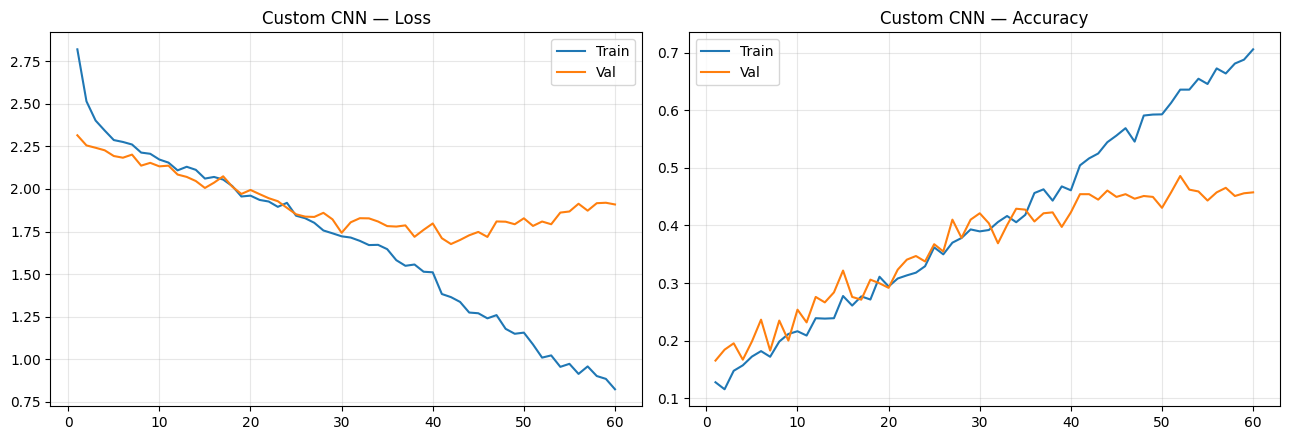

  EVALUATION — Custom CNN (best checkpoint)
Test Accuracy (Custom CNN): 0.4772


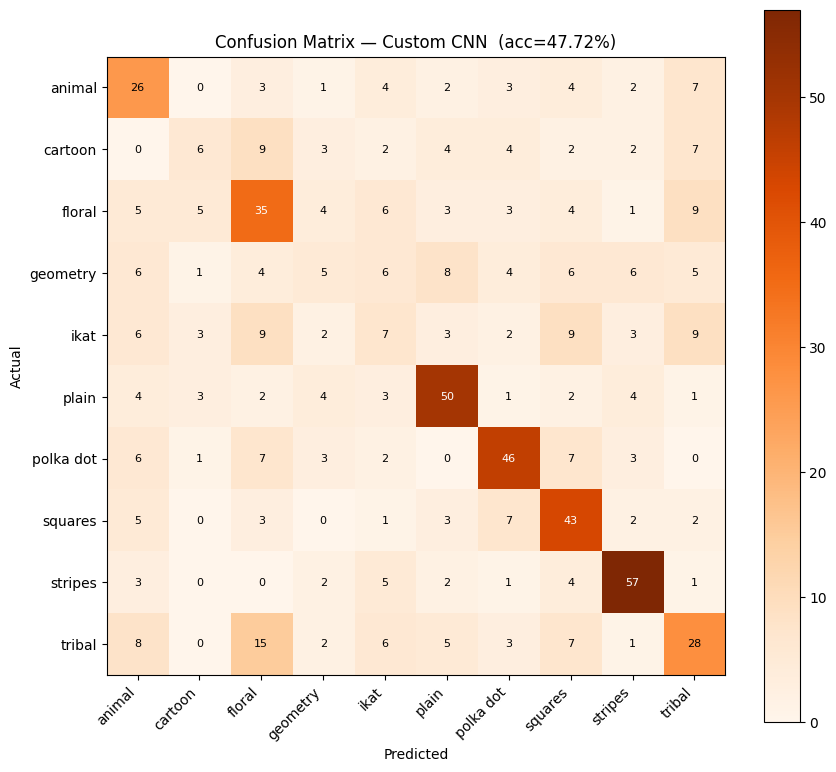

In [10]:
print("  TRAINING — Custom CNN")
 
loss_fn_cnn   = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.Adam(cnn_model.parameters(), lr=CNN_LR, weight_decay=CNN_WEIGHT_DECAY)
scheduler_cnn = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnn, mode='max', factor=0.5, patience=5)
 
cnn_history       = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
cnn_best_val_acc  = 0.0
cnn_no_improve    = 0
cnn_ckpt_path     = os.path.join(OUTPUT_DIR, "cnn_best_model.pth")
 
t_start = time.time()
for epoch in range(1, CNN_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = run_epoch(cnn_model, train_loader, loss_fn_cnn, optimizer_cnn, train_mode=True)
    val_loss,   val_acc   = run_epoch(cnn_model, val_loader,   loss_fn_cnn, train_mode=False)
    scheduler_cnn.step(val_acc)
    current_lr = optimizer_cnn.param_groups[0]['lr']
 
    cnn_history["train_loss"].append(train_loss)
    cnn_history["train_acc"].append(train_acc)
    cnn_history["val_loss"].append(val_loss)
    cnn_history["val_acc"].append(val_acc)
 
    improved = val_acc > cnn_best_val_acc
    tag = "  ← best" if improved else ""
    print(f"Epoch {epoch:3d}/{CNN_EPOCHS} | loss {train_loss:.4f} acc {train_acc:.4f} "
          f"| val_loss {val_loss:.4f} val_acc {val_acc:.4f} | lr {current_lr:.2e} | {time.time()-t0:.1f}s{tag}")
 
    if improved:
        cnn_best_val_acc = val_acc
        cnn_no_improve   = 0
        torch.save({
            "model_state_dict": cnn_model.state_dict(),
            "architecture":     "PatSeCNN",
            "epoch":            epoch,
            "val_acc":          val_acc,
            "num_classes":      NUM_CLASSES,
            "classes":          CLASSES,
            "label_to_idx":     label_to_idx,
            "img_size":         IMG_SIZE,
            "mean":             MEAN,
            "std":              STD,
        }, cnn_ckpt_path)
    else:
        cnn_no_improve += 1
 
    if cnn_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping (CNN): no improvement for {EARLY_STOP_PATIENCE} epochs.")
        break
 
print(f"\nCNN training done in {(time.time()-t_start)/60:.1f} min.  Best val acc: {cnn_best_val_acc:.4f}")
 
# Training curves
plot_history(cnn_history, "Custom CNN", "training_curves_cnn.png")
 

print("  EVALUATION — Custom CNN (best checkpoint)")
 
ckpt = torch.load(cnn_ckpt_path, map_location=device)
cnn_model.load_state_dict(ckpt["model_state_dict"])
 
cnn_test_acc = evaluate_and_plot_cm(
    cnn_model, test_loader,
    title="Custom CNN",
    save_name="confusion_matrix_cnn.png"
)

  TRAINING — ResNet50 (pretrained, 2-phase fine-tune)
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 168MB/s] 


ResNet50 — Total params: 23,528,522  |  Phase-1 trainable: 20,490
Epoch   1/40 [    head] | loss 2.0945 acc 0.2837 | val_loss 1.9753 val_acc 0.3833 | lr 1.00e-03 | 13.7s  ← best
Epoch   2/40 [    head] | loss 1.8686 acc 0.4343 | val_loss 1.8154 val_acc 0.4779 | lr 1.00e-03 | 13.9s  ← best
Epoch   3/40 [    head] | loss 1.7375 acc 0.5035 | val_loss 1.7370 val_acc 0.5158 | lr 1.00e-03 | 13.7s  ← best
Epoch   4/40 [    head] | loss 1.6806 acc 0.5106 | val_loss 1.6934 val_acc 0.5331 | lr 1.00e-03 | 13.4s  ← best
Epoch   5/40 [    head] | loss 1.6197 acc 0.5414 | val_loss 1.6749 val_acc 0.5410 | lr 1.00e-03 | 13.6s  ← best

--- Unfreezing backbone → fine-tune LR=5.0e-05 ---

Epoch   6/40 [finetune] | loss 1.5225 acc 0.5735 | val_loss 1.5182 val_acc 0.6167 | lr 5.00e-05 | 34.4s  ← best
Epoch   7/40 [finetune] | loss 1.3842 acc 0.6332 | val_loss 1.4653 val_acc 0.6262 | lr 5.00e-05 | 35.1s  ← best
Epoch   8/40 [finetune] | loss 1.2538 acc 0.6906 | val_loss 1.4319 val_acc 0.6309 | lr 5.00e-05 |

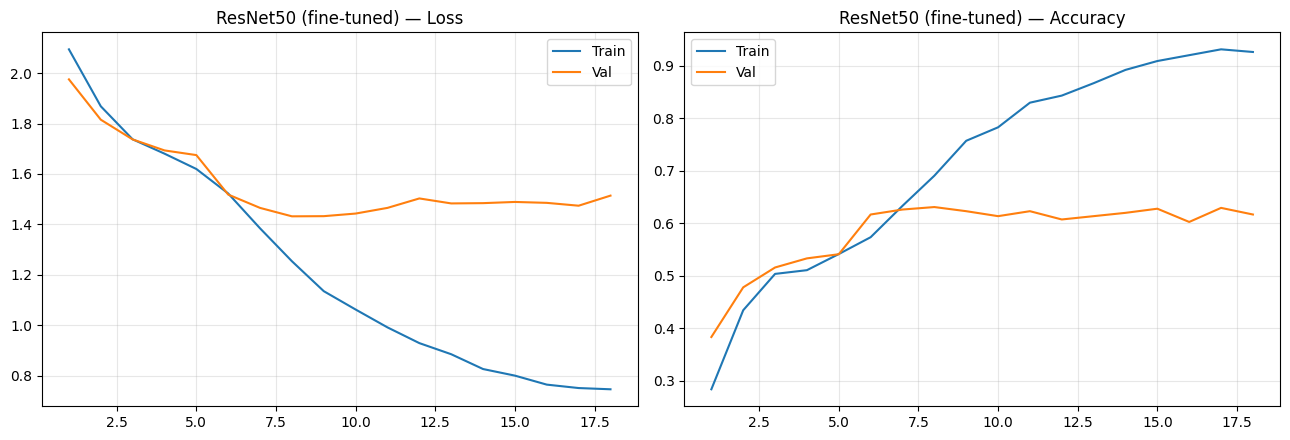

  EVALUATION — ResNet50 (best checkpoint)
Test Accuracy (ResNet50): 0.6063


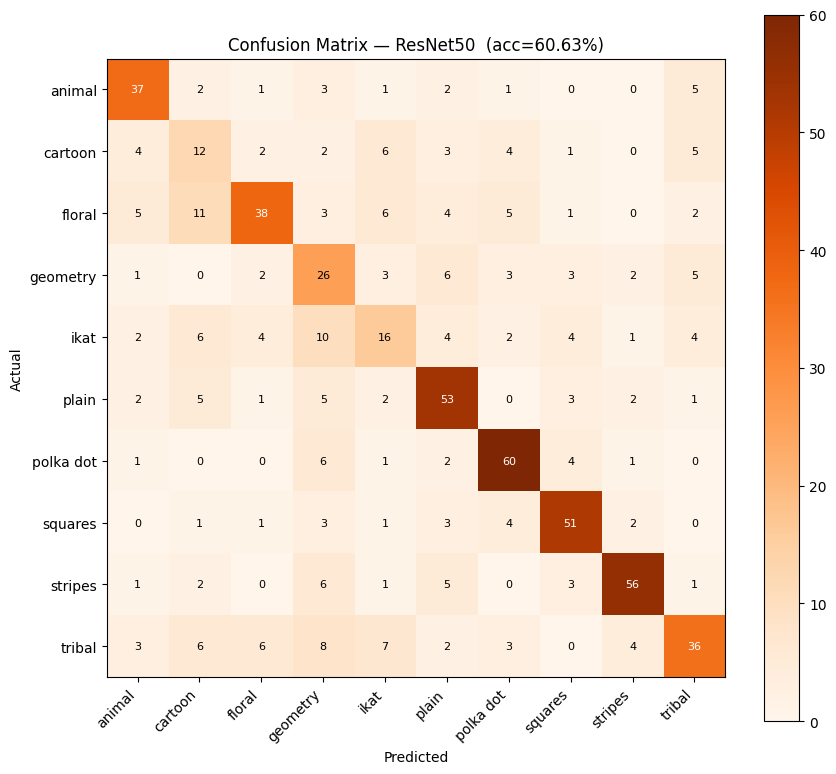

In [18]:
print("  TRAINING — ResNet50 (pretrained, 2-phase fine-tune)")

def build_resnet50(num_classes):
    weights = ResNet50_Weights.IMAGENET1K_V2
    net = resnet50(weights=weights)
    in_features = net.fc.in_features          # 2048
    net.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes),
    )
    return net
 
 
r50_model   = build_resnet50(NUM_CLASSES).to(device)
loss_fn_r50 = nn.CrossEntropyLoss(weight=loss_class_weights, label_smoothing=0.1)
 
# Phase 1: freeze backbone, train head only
for param in r50_model.parameters():
    param.requires_grad = False
for param in r50_model.fc.parameters():
    param.requires_grad = True
 
optimizer_r50 = torch.optim.Adam(
    [p for p in r50_model.parameters() if p.requires_grad],
    lr=R50_HEAD_LR, weight_decay=R50_WEIGHT_DECAY
)
scheduler_r50 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_r50, mode='max', factor=0.5, patience=5)
 
n_total     = sum(p.numel() for p in r50_model.parameters())
n_trainable = sum(p.numel() for p in r50_model.parameters() if p.requires_grad)
print(f"ResNet50 — Total params: {n_total:,}  |  Phase-1 trainable: {n_trainable:,}")
 
r50_history      = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "phase": []}
r50_best_val_acc = 0.0
r50_no_improve   = 0
r50_ckpt_path    = os.path.join(OUTPUT_DIR, "resnet50_best_model.pth")
 
t_start = time.time()
for epoch in range(1, R50_EPOCHS + 1):
    t0 = time.time()
 
    # ── Phase transition: unfreeze backbone ──
    if epoch == R50_HEAD_EPOCHS + 1:
        print(f"\n--- Unfreezing backbone → fine-tune LR={R50_FINETUNE_LR:.1e} ---\n")
        for param in r50_model.parameters():
            param.requires_grad = True
        optimizer_r50 = torch.optim.Adam(
            r50_model.parameters(), lr=R50_FINETUNE_LR, weight_decay=R50_WEIGHT_DECAY
        )
        scheduler_r50 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_r50, mode='max', factor=0.5, patience=5)
        r50_no_improve = 0   # reset early-stop counter for phase 2
 
    phase = "head" if epoch <= R50_HEAD_EPOCHS else "finetune"
    train_loss, train_acc = run_epoch(r50_model, train_loader, loss_fn_r50, optimizer_r50, train_mode=True)
    val_loss,   val_acc   = run_epoch(r50_model, val_loader,   loss_fn_r50, train_mode=False)
    scheduler_r50.step(val_acc)
    current_lr = optimizer_r50.param_groups[0]['lr']
 
    r50_history["train_loss"].append(train_loss)
    r50_history["train_acc"].append(train_acc)
    r50_history["val_loss"].append(val_loss)
    r50_history["val_acc"].append(val_acc)
    r50_history["phase"].append(phase)
 
    improved = val_acc > r50_best_val_acc
    tag = "  ← best" if improved else ""
    print(f"Epoch {epoch:3d}/{R50_EPOCHS} [{phase:>8}] | loss {train_loss:.4f} acc {train_acc:.4f} "
          f"| val_loss {val_loss:.4f} val_acc {val_acc:.4f} | lr {current_lr:.2e} | {time.time()-t0:.1f}s{tag}")
 
    if improved:
        r50_best_val_acc = val_acc
        r50_no_improve   = 0
        torch.save({
            "model_state_dict": r50_model.state_dict(),
            "architecture":     "resnet50",
            "epoch":            epoch,
            "val_acc":          val_acc,
            "num_classes":      NUM_CLASSES,
            "classes":          CLASSES,
            "label_to_idx":     label_to_idx,
            "img_size":         IMG_SIZE,
            "mean":             MEAN,
            "std":              STD,
        }, r50_ckpt_path)
    else:
        r50_no_improve += 1
 
    if r50_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping (ResNet50): no improvement for {EARLY_STOP_PATIENCE} epochs.")
        break
 
print(f"\nResNet50 training done in {(time.time()-t_start)/60:.1f} min.  Best val acc: {r50_best_val_acc:.4f}")
 
# Training curves
plot_history(r50_history, "ResNet50 (fine-tuned)", "training_curves_resnet50.png")
 
print("  EVALUATION — ResNet50 (best checkpoint)")
 
ckpt = torch.load(r50_ckpt_path, map_location=device)
r50_model.load_state_dict(ckpt["model_state_dict"])
 
r50_test_acc = evaluate_and_plot_cm(
    r50_model, test_loader,
    title="ResNet50",
    save_name="confusion_matrix_resnet50.png"
)

In [19]:
print("  FINAL SUMMARY")

print(f"""
  Model         | Best Val Acc | Test Acc
  ─────────────────────────────────────────
  Custom CNN    |  {cnn_best_val_acc:.4f}      |  {cnn_test_acc:.4f}
  ResNet50      |  {r50_best_val_acc:.4f}      |  {r50_test_acc:.4f}
 
  Output files in {OUTPUT_DIR}:
    patse_dataset.csv           — image index
    cnn_best_model.pth          — best CNN weights
    resnet50_best_model.pth     — best ResNet50 weights
    training_curves_cnn.png
    training_curves_resnet50.png
    confusion_matrix_cnn.png
    confusion_matrix_resnet50.png
 
  Checkpoint keys (both models):
    model_state_dict, architecture, epoch, val_acc,
    num_classes, classes, label_to_idx, img_size, mean, std
 
  To load for inference / FastAPI:
    ckpt  = torch.load("resnet50_best_model.pth", map_location="cpu")
    model = build_resnet50(ckpt["num_classes"])
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
""")

  FINAL SUMMARY

  Model         | Best Val Acc | Test Acc
  ─────────────────────────────────────────
  Custom CNN    |  0.4858      |  0.4772
  ResNet50      |  0.6309      |  0.6063
 
  Output files in /kaggle/working/:
    patse_dataset.csv           — image index
    cnn_best_model.pth          — best CNN weights
    resnet50_best_model.pth     — best ResNet50 weights
    training_curves_cnn.png
    training_curves_resnet50.png
    confusion_matrix_cnn.png
    confusion_matrix_resnet50.png
 
  Checkpoint keys (both models):
    model_state_dict, architecture, epoch, val_acc,
    num_classes, classes, label_to_idx, img_size, mean, std
 
  To load for inference / FastAPI:
    ckpt  = torch.load("resnet50_best_model.pth", map_location="cpu")
    model = build_resnet50(ckpt["num_classes"])
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

